**DATA CLEANING**

In [2]:
import numpy as np
import pandas as pd

In [8]:
df=pd.DataFrame({'Age':[15,18,'18',19.4,'20+'],'Gender':['male','female','female','male','male']})
df

,Age,Gender
0,15,male
1,18,female
2,18,female
3,19.4,male
4,20+,male


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Age     5 non-null      object
 1   Gender  5 non-null      object
dtypes: object(2)
memory usage: 212.0+ bytes


***1 Wrong Data, Solution:Replace***

In [21]:
df['Age']=df['Age'].replace({"20+":20})
df

,Age,Gender
0,15,male
1,18,female
2,18,female
3,19.4,male
4,20,male


***wrong datatype, Solution:convert datatype***

In [24]:
df['Age']=df['Age'].astype('float')
df

,Age,Gender
0,15.0,male
1,18.0,female
2,18.0,female
3,19.4,male
4,20.0,male


In [26]:
# to check duplicate records
df.duplicated()

0    False
1    False
2     True
3    False
4    False
dtype: bool

In [28]:
# to extract non duplicate records
df[~df.duplicated()]

,Age,Gender
0,15.0,male
1,18.0,female
3,19.4,male
4,20.0,male


In [30]:
df=df.drop_duplicates()
df

,Age,Gender
0,15.0,male
1,18.0,female
3,19.4,male
4,20.0,male


In [32]:
# to remove the dupllicates
df=df.drop_duplicates(ignore_index=True)
df

,Age,Gender
0,15.0,male
1,18.0,female
2,19.4,male
3,20.0,male


**Missing values,**
**solution:Either remove or replace**

In [5]:
import numpy as np
import pandas as pd

In [66]:
df = pd.DataFrame({"Age":[15,np.nan,24,19,20,22],"Gender":["male",np.nan,"female",np.nan,"male","female"]})
df

,Age,Gender
0,15.0,male
1,NaN,NaN
2,24.0,female
3,19.0,NaN
4,20.0,male
5,22.0,female


In [68]:
df.isnull()

,Age,Gender
0,False,False
1,True,True
2,False,False
3,False,True
4,False,False
5,False,False


In [70]:
df.isnull().sum()

Age       1
Gender    2
dtype: int64

In [72]:
#to check the percentage of the missing value in each variable
df.isnull().sum()/len(df)*100

Age       16.666667
Gender    33.333333
dtype: float64

In [28]:
#to extract the missing values
df[df['Age'].isnull()]

,Age,Gender
1,NaN,NaN


In [74]:
df[df['Gender'].isnull()]

,Age,Gender
1,NaN,NaN
3,19.0,NaN


In [32]:
df.drop(index=[1])

,Age,Gender
0,15.0,male
2,24.0,female
3,19.0,NaN
4,20.0,male
5,22.0,female


In [40]:
#OR
df[df['Gender'].isnull()].index.tolist()

[1, 3]

In [76]:
df2=df.drop(index=[1, 3])
df2

,Age,Gender
0,15.0,male
2,24.0,female
4,20.0,male
5,22.0,female


In [80]:
df2.drop_duplicates(ignore_index=True)


,Age,Gender
0,15.0,male
1,24.0,female
2,20.0,male
3,22.0,female


**Option2**

In [94]:
#to fill with a value
df['Age'].fillna(20)

0    15.0
1    20.0
2    24.0
3    19.0
4    20.0
5    22.0
Name: Age, dtype: float64

In [96]:
#to fill with a mean
df['Age'].fillna(df['Age'].mean())

0    15.0
1    20.0
2    24.0
3    19.0
4    20.0
5    22.0
Name: Age, dtype: float64

In [98]:
#to fill with a median
df['Age'].fillna(df['Age'].median())

0    15.0
1    20.0
2    24.0
3    19.0
4    20.0
5    22.0
Name: Age, dtype: float64

In [100]:
#for descreate variable using mode
df["Gender"].mode()

0    female
1      male
Name: Gender, dtype: object

In [102]:
df["Gender"].fillna(df['Gender'].mode())

0      male
1      male
2    female
3       NaN
4      male
5    female
Name: Gender, dtype: object

In [104]:
df["Gender"].mode()[0]


'female'

In [110]:
df["Gender"].fillna(df['Gender'].mode()[0])

0      male
1    female
2    female
3    female
4      male
5    female
Name: Gender, dtype: object

**OUTLIERS**

In [7]:
df3=pd.DataFrame({"marks":[10,11,12,25,25,27,31,33,34,34,36,36,43,50,59]})
df3.head()

,marks
0,10
1,11
2,12
3,25
4,25


In [87]:
df.shape

(6, 2)

<Axes: ylabel='marks'>

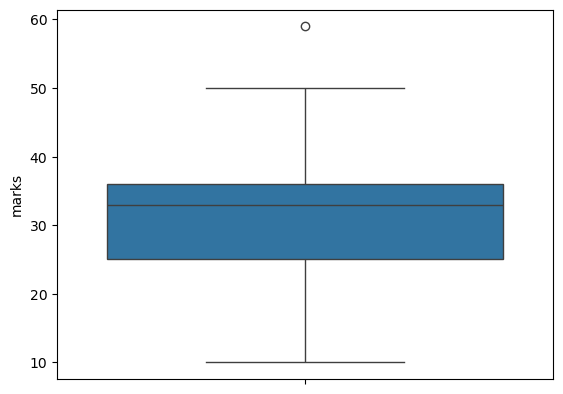

In [146]:
import seaborn as sns
sns.boxplot(df3["marks"])


**Indentifying outliers based on IQR**

In [13]:
#calculate Q1
Q1=df3["marks"].quantile(0.25)
print("Q1:",Q1)

Q1: 25.0


In [17]:
#calculate Q1
Q3=df3["marks"].quantile(0.75)
print("Q3:",Q3)

Q3: 36.0


In [19]:
#calculate IQR
IQR=Q3-Q1
print("IQR:",IQR)

IQR: 11.0


In [21]:
#calculate lower limit
lower_limit=Q1-(1.5*IQR)
lower_limit

8.5

In [23]:
#calculate upper limit
upper_limit=Q3+(1.5*IQR)
upper_limit

52.5

In [25]:
#outliers data
df3[(df3["marks"]<lower_limit)|(df3["marks"]>upper_limit)]

,marks
14,59


In [160]:
df3['marks']=df3['marks'].clip(lower=8.5,upper=52.5)
df3

,marks
0,10.0
1,11.0
2,12.0
3,25.0
4,25.0
5,27.0
6,31.0
7,33.0
8,34.0
9,34.0
